HASIL KLASIFIKASI RANDOM FOREST
              precision    recall  f1-score   support

           0       0.72      0.96      0.83        52
           1       0.80      0.30      0.43        27

    accuracy                           0.73        79
   macro avg       0.76      0.63      0.63        79
weighted avg       0.75      0.73      0.69        79



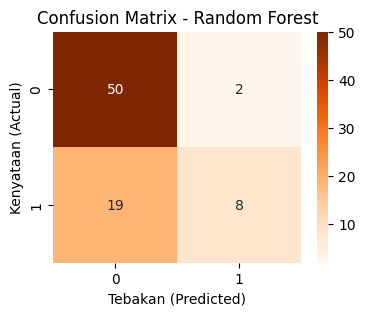

Akurasi Random Forest: 0.7341772151898734


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

df = pd.read_excel('Book1.xlsx')
df['Label'] = np.where(df['G3'] < 10, 1, 0)
df_model = df.drop(['G1', 'G2', 'G3'], axis=1)
le = LabelEncoder()
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('Label', axis=1)
y = df_model['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("HASIL KLASIFIKASI RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(4,3))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Kenyataan (Actual)')
plt.xlabel('Tebakan (Predicted)')
plt.show()

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Akurasi Random Forest:", acc_rf)